# Gaze Calibration & Sampling Frequency Validation

### Overview
This notebook evaluates a dynamic recalibration algorithm by analyzing the spatial coupling between gaze axes ($X$ and $Y$) and computing physical hardware timing intervals.

### Core Metrics Checked
* **Pearson Correlation ($r$)**: Compares $X/Y$ spatial tracking coupling before and after applying the calibration algorithm.
* **Inter-Sample Interval (ISI)**: Computes the precise chronological spacing between consecutive samples to measure hardware consistency.
* **Sampling Rate (Hz)**: Derives the physical temporal frequency ($1 / \text{ISI}$) to check for frame drops against the 60 Hz target.
* **Spatial Precision (RMS)**: Quantifies trial-by-trial coordinate jitter using sequential root-mean-square distance.

### Pipeline Execution
* **Incremental Processing**: Skips previously evaluated files to optimize compute time and logs metrics sequentially.
* **Vectorized Post-Processing**: Safely parses tuple outputs (`ast.literal_eval`) and formats raw data for the final dashboard.
* **Dashboard Rendering**: Plots high-resolution frequency histograms (zoomed to 57–62 Hz), spatial precision spreads, and correlation shifts.


In [ ]:


import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

current_dir = Path(os.getcwd())
sys.path.append(str(current_dir.parent))

from python_scripts.util import *

data_type = 'moving' # Valid types = [moving, static]

In [3]:
# Ensure that the recalibrated dataset exists for all participants before computing error plots
%run ../python_scripts/recalibrate_data.py --type {data_type}

Starting execution. Total participants to process: 36


Overall Progress: 100%|██████████| 36/36 [00:00<00:00, 35976.87participant/s]


Script execution completed successfully!


In [ ]:
target_dir = os.path.join('..', f"recalibrated_data_{data_type}")
exclusions = ['error_df.csv', 'precision_df.csv', 'precision_saccade_df.csv', 'precision_smooth_df.csv']
file_names = [
    f for f in os.listdir(target_dir) 
    if os.path.isfile(os.path.join(target_dir, f)) and f not in exclusions and "callibrate" in f
]

precision_df = pd.DataFrame(columns=['Name', 'pearsonr', 'pearsonr_recal', 'ISI', 'precision']) 
precision_df_path = os.path.join('..', f"recalibrated_data_{data_type}", 'precision_df.csv')


In [4]:
if os.path.exists(precision_df_path):
    precision_df = pd.read_csv(precision_df_path)



# Optimized and bug-free loop
for participant_task in file_names:
    base_name = participant_task.rsplit(".", 1)[0]

    # Skip already processed files
    if base_name in precision_df["Name"].values:
        continue

    # 1. Load the file ONLY ONCE
    file_path = os.path.join("..", "recalibrated_data_moving", participant_task)
    df = pd.read_csv(file_path, index_col=False)

    # Handle edge case: Skip empty files or files with insufficient data
    if len(df) < 2:
        print(f"Skipping {participant_task}: Not enough rows.")
        continue

    # 2. Calculate Pearson metrics
    [pr, pr_recal] = pearsonr_from_df(df)

    # 3. Vectorized / Cleaned Math Loop
    rms_error = 0
    isi = 0 # Inter-Sample Interval

    # Reset index ensures 'index - 1' is always mathematically safe and sequential
    df_clean = df.reset_index(drop=True)

    for index in range(1, len(df_clean)):
        # Previous row values
        prev_row = df_clean.iloc[index - 1]
        curr_row = df_clean.iloc[index]

        p = [prev_row["gaze_vis_x"], prev_row["gaze_vis_y"]]
        q = [curr_row["gaze_vis_x"], curr_row["gaze_vis_y"]]

        rms_error += math.dist(p, q) ** 2
        isi += curr_row["seconds"] - prev_row["seconds"]

    # Finalize metrics
    total_intervals = len(df_clean) - 1
    rms_error = math.sqrt(rms_error / total_intervals)
    isi /= total_intervals

    # 4. Safely append to the end of precision_df using its own length
    precision_df.loc[len(precision_df)] = [
        base_name,
        pr,
        pr_recal,
        isi,
        rms_error,
    ]

    # Save progress after each file
    precision_df.to_csv(precision_df_path, index=False)


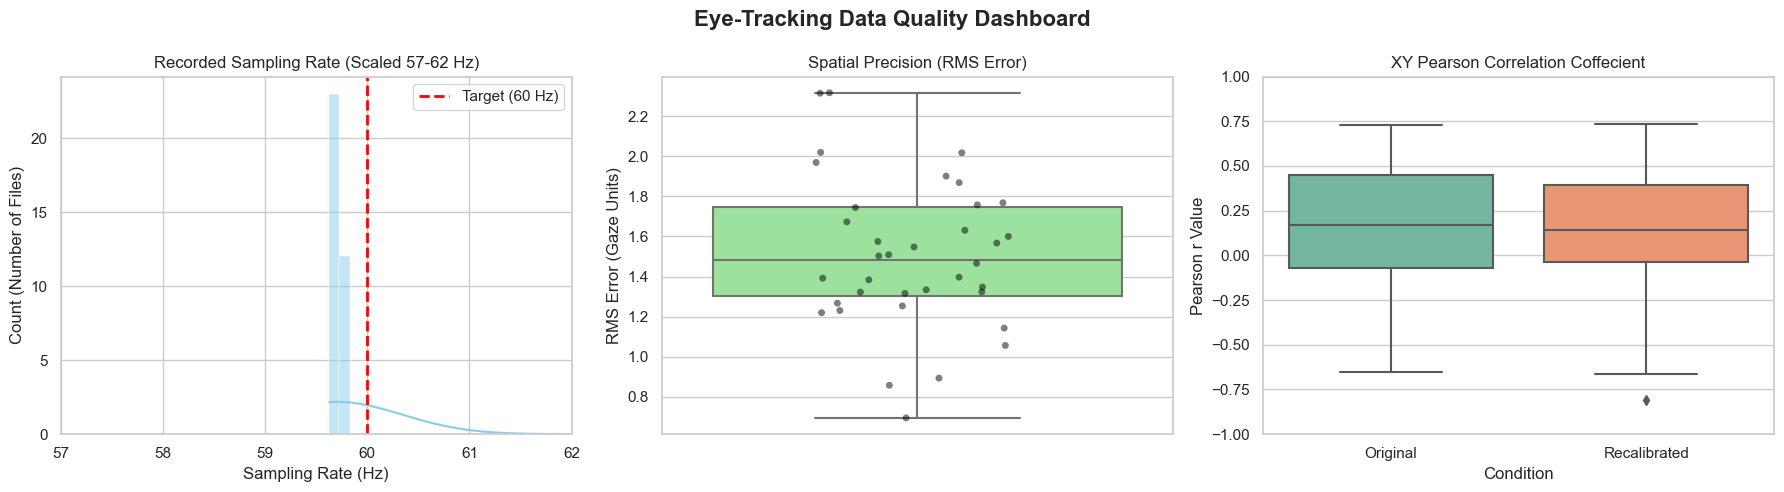

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast
import numpy as np

# 1. Clean the correlation columns to extract ONLY the r-value
def extract_r(val):
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return None
    if isinstance(val, (tuple, list)):
        return val[0]
    return val

# Create temporary dataframe for plotting
plot_df = precision_df.copy()
plot_df['r_original'] = plot_df['pearsonr'].apply(extract_r)
plot_df['r_recalibrated'] = plot_df['pearsonr_recal'].apply(extract_r)

# Calculate the Inverse of ISI to get the Sampling Rate (Hz)
plot_df['Sampling_Rate_Hz'] = np.where(plot_df['ISI'] > 0, 1 / plot_df['ISI'], 0)

# 2. Set up the visual layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Eye-Tracking Data Quality Dashboard', fontsize=16, fontweight='bold')

# --- Plot 1: Scaled Sampling Rate Distribution (Hz) ---
target_hz = 60  # Your hardware target

# binwidth=0.1 creates high-resolution bars to see minor frame variations
sns.histplot(data=plot_df, x='Sampling_Rate_Hz', binwidth=0.1, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(target_hz, color='red', linestyle='--', linewidth=2, label=f'Target ({target_hz} Hz)')

# Zooms in specifically on the 57 to 62 Hz window
axes[0].set_xlim(57, 62) 

axes[0].set_title('Recorded Sampling Rate (Scaled 57-62 Hz)')
axes[0].set_xlabel('Sampling Rate (Hz)')
axes[0].set_ylabel('Count (Number of Files)')
axes[0].legend()

# --- Plot 2: Spatial Precision (RMS Error) ---
sns.boxplot(data=plot_df, y='precision', ax=axes[1], color='lightgreen')
sns.stripplot(data=plot_df, y='precision', ax=axes[1], color='black', alpha=0.5, jitter=0.2)
axes[1].set_title('Spatial Precision (RMS Error)')
axes[1].set_ylabel('RMS Error (Gaze Units)')

# --- Plot 3: Pearson Correlation Comparison ---
df_melted = plot_df.melt(id_vars=['Name'], value_vars=['r_original', 'r_recalibrated'], 
                              var_name='Condition', value_name='Correlation')
df_melted['Condition'] = df_melted['Condition'].replace({'r_original': 'Original', 'r_recalibrated': 'Recalibrated'})

sns.boxplot(data=df_melted, x='Condition', y='Correlation', ax=axes[2], palette='Set2')
axes[2].set_title('XY Pearson Correlation Coffecient')
axes[2].set_ylabel('Pearson r Value')
axes[2].set_ylim(-1, 1)

plt.tight_layout()
plt.show()
